# 🏆 Proyecto Final 2: Estimación del Valor de Alquiler de Propiedades
### Curso: **Machine Learning con Python** (IFCD093PO)
**Duración estimada:** 6 horas

---

## 🎯 Objetivo del Proyecto

En este segundo proyecto final, aplicarás tus conocimientos de **regresión** para resolver otro problema de negocio común: estimar el precio de un bien basándose en sus características. Específicamente, construiremos un modelo para predecir el valor de alquiler de propiedades.

Este tipo de modelo es fundamental para portales inmobiliarios, inversores y agencias para determinar precios competitivos y justos. Seguiremos de nuevo el flujo de trabajo completo de Machine Learning.

1.  **Análisis Exploratorio de Datos (EDA)**: Investigar las características de las propiedades y su relación con el precio.
2.  **Preprocesamiento y Preparación de Datos**: Limpiar y transformar los datos para los modelos de regresión.
3.  **Modelado**: Entrenar varios modelos de regresión (Regresión Lineal con Regularización, Random Forest, Gradient Boosting).
4.  **Evaluación y Selección del Modelo**: Comparar los modelos usando métricas de regresión (MAE, MSE, RMSE, R²) y elegir el más performante.
5.  **Conclusiones**: Interpretar el modelo final para entender qué características influyen más en el precio del alquiler.

**Dataset:** Usaremos un dataset de alquileres de casas de Brasil, disponible en Kaggle. Contiene características como el área, número de habitaciones, baños, plazas de garaje, y si se aceptan animales, entre otros.

---

## 📚 Flujo de Trabajo

1. [Carga y Comprensión Inicial de los Datos](#1-carga)
2. [Análisis Exploratorio de Datos (EDA)](#2-eda)
   - [Distribución de la Variable Objetivo (Precio)](#2.1-dist-precio)
   - [Análisis de Características Numéricas](#2.2-analisis-num)
   - [Correlaciones](#2.3-correlacion)
3. [Preprocesamiento de Datos](#3-prepro)
   - [Limpieza y Transformación de Características](#3.1-limpieza)
   - [Codificación y Escalado](#3.2-cod-esc)
   - [División en Train/Test](#3.3-split)
4. [Modelado y Entrenamiento](#4-modelado)
   - [Modelo Base: Ridge Regression](#4.1-ridge)
   - [Modelo de Ensemble: Random Forest Regressor](#4.2-randomforest)
   - [Modelo de Competición: XGBoost Regressor](#4.3-xgboost)
5. [Evaluación de Modelos](#5-evaluacion)
   - [Comparación de Métricas (RMSE, R²)](#5.1-metricas)
   - [Análisis de Residuos](#5.2-residuos)
   - [Selección del Mejor Modelo](#5.3-seleccion)
6. [Análisis de Importancia de Características](#6-features)
7. [Conclusiones](#7-conclusiones)

---

## 📥 1. Carga y Comprensión Inicial de los Datos <a id='1-carga'></a>

Comenzamos cargando el dataset y realizando una primera inspección.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuraciones de visualización
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 6)

# Cargar el dataset
# Asegúrate de tener el archivo 'houses_to_rent_v2.csv' en la misma carpeta.
try:
    df = pd.read_csv('houses_to_rent_v2.csv')
except FileNotFoundError:
    print("Archivo no encontrado. Por favor, descarga 'houses_to_rent_v2.csv' de Kaggle y colócalo en la carpeta del proyecto.")

if 'df' in locals():
    print("Dataset cargado exitosamente.")
    print("Dimensiones del dataset:", df.shape)
    print("\nPrimeras 5 filas:")
    display(df.head())
    
    print("\nInformación del dataset:")
    df.info()
    
    print("\nEstadísticas descriptivas:")
    display(df.describe())

Dataset cargado exitosamente.
Dimensiones del dataset: (10692, 13)

Primeras 5 filas:


,city,area,rooms,bathroom,parking spaces,floor,animal,furniture,hoa (R$),rent amount (R$),property tax (R$),fire insurance (R$),total (R$)
0,São Paulo,70,2,1,1,7,acept,furnished,2065,3300,211,42,5618
1,São Paulo,320,4,4,0,20,acept,not furnished,1200,4960,1750,63,7973
2,Porto Alegre,80,1,1,1,6,acept,not furnished,1000,2800,0,41,3841
3,Porto Alegre,51,2,1,0,2,acept,not furnished,270,1112,22,17,1421
4,São Paulo,25,1,1,0,1,not acept,not furnished,0,800,25,11,836



Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10692 entries, 0 to 10691
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   city                 10692 non-null  object
 1   area                 10692 non-null  int64 
 2   rooms                10692 non-null  int64 
 3   bathroom             10692 non-null  int64 
 4   parking spaces       10692 non-null  int64 
 5   floor                10692 non-null  object
 6   animal               10692 non-null  object
 7   furniture            10692 non-null  object
 8   hoa (R$)             10692 non-null  int64 
 9   rent amount (R$)     10692 non-null  int64 
 10  property tax (R$)    10692 non-null  int64 
 11  fire insurance (R$)  10692 non-null  int64 
 12  total (R$)           10692 non-null  int64 
dtypes: int64(9), object(4)
memory usage: 1.1+ MB

Estadísticas descriptivas:


,area,rooms,bathroom,parking spaces,hoa (R$),rent amount (R$),property tax (R$),fire insurance (R$),total (R$)
count,10692.000000,10692.000000,10692.000000,10692.000000,1.069200e+04,10692.000000,10692.000000,10692.000000,1.069200e+04
mean,149.217920,2.506079,2.236813,1.609147,1.174022e+03,3896.247194,366.704358,53.300879,5.490487e+03
std,537.016942,1.171266,1.407198,1.589521,1.559231e+04,3408.545518,3107.832321,47.768031,1.648473e+04
min,11.000000,1.000000,1.000000,0.000000,0.000000e+00,450.000000,0.000000,3.000000,4.990000e+02
25%,56.000000,2.000000,1.000000,0.000000,1.700000e+02,1530.000000,38.000000,21.000000,2.061750e+03
50%,90.000000,2.000000,2.000000,1.000000,5.600000e+02,2661.000000,125.000000,36.000000,3.581500e+03
75%,182.000000,3.000000,3.000000,2.000000,1.237500e+03,5000.000000,375.000000,68.000000,6.768000e+03
max,46335.000000,13.000000,10.000000,12.000000,1.117000e+06,45000.000000,313700.000000,677.000000,1.120000e+06


**Observaciones Iniciales:**
- Tenemos varias columnas numéricas (`area`, `rooms`, `bathroom`, etc.) y algunas categóricas (`city`, `animal`, `furniture`).
- La variable objetivo será la suma de varias columnas de costes. En este dataset, la columna `total (R$)` ya representa esto.
- Los nombres de las columnas contienen caracteres especiales y espacios, lo que puede ser incómodo. Sería bueno limpiarlos.

---

## 📊 2. Análisis Exploratorio de Datos (EDA) <a id='2-eda'></a>

Investiguemos la distribución de la variable objetivo y su relación con otras características.

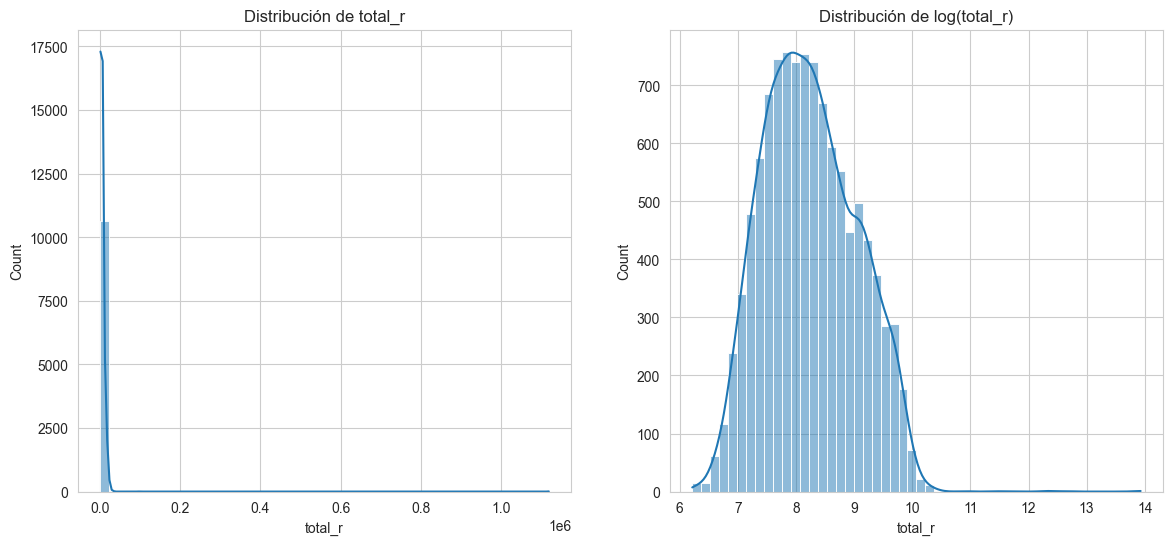

La distribución del precio está muy sesgada. Los modelos de regresión lineal funcionan mejor con variables objetivo distribuidas normalmente. Aplicar una transformación logarítmica parece una buena idea.


In [3]:
if 'df' in locals():
    # Limpiar nombres de columnas
    df.columns = [col.replace(' ', '_').replace('(', '').replace(')', '').replace('$', '').lower() for col in df.columns]
    
    # Definir la variable objetivo
    target = 'total_r'
    
    # Análisis de la variable objetivo
    plt.figure(figsize=(14, 6))
    
    plt.subplot(1, 2, 1)
    sns.histplot(df[target], kde=True, bins=50)
    plt.title(f'Distribución de {target}')
    
    # La distribución está muy sesgada a la derecha. Una transformación logarítmica puede ayudar.
    plt.subplot(1, 2, 2)
    sns.histplot(np.log1p(df[target]), kde=True, bins=50)
    plt.title(f'Distribución de log({target})')
    plt.show()
    
    print("La distribución del precio está muy sesgada. Los modelos de regresión lineal funcionan mejor con variables objetivo distribuidas normalmente. Aplicar una transformación logarítmica parece una buena idea.")

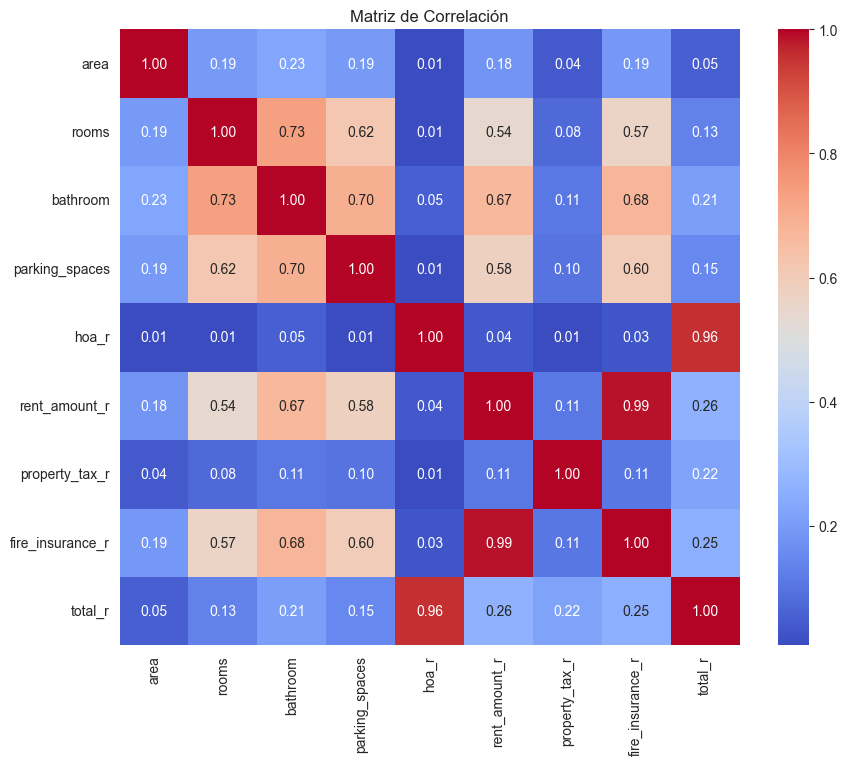

In [5]:
if 'df' in locals():
    # Correlación entre variables numéricas
    plt.figure(figsize=(10, 8))
    numeric_df = df.select_dtypes(include=[np.number])
    corr_matrix = numeric_df.corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Matriz de Correlación')
    plt.show()

**Observaciones del EDA:**
- Como era de esperar, `rent_amount_r` y `hoa_r` (cuota de comunidad) están altamente correlacionados con el `total_r`, ya que son sus componentes. Para evitar multicolinealidad y fuga de datos, **debemos eliminar estas columnas y predecir `total_r` a partir de las características de la propiedad**.
- `area`, `rooms`, `bathroom` y `parking_spaces` tienen una correlación positiva con el precio total, lo cual tiene sentido.
- La transformación logarítmica de la variable objetivo la hace mucho más simétrica, lo que ayudará a los modelos lineales.

---

## ⚙️ 3. Preprocesamiento de Datos <a id='3-prepro'></a>

Preparamos los datos para el modelado: limpiamos, codificamos, escalamos y dividimos.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

if 'df' in locals():
    # Eliminar columnas que causan data leakage o no son útiles
    df_processed = df.drop(['hoa_r', 'rent_amount_r', 'property_tax_r', 'fire_insurance_r'], axis=1)

    # Convertir categóricas binarias a 0/1
    df_processed['animal'] = df_processed['animal'].apply(lambda x: 1 if x == 'acept' else 0)
    df_processed['furniture'] = df_processed['furniture'].apply(lambda x: 1 if x == 'furnished' else 0)

    # Aplicar transformación logarítmica a la variable objetivo
    df_processed[target] = np.log1p(df_processed[target])

    # Separar X e y
    X = df_processed.drop(target, axis=1)
    y = df_processed[target]

    # Identificar columnas numéricas y categóricas (la única que queda es 'city')
    numerical_features = X.select_dtypes(include=np.number).columns.tolist()
    categorical_features = ['city']

    # Crear pipelines de preprocesamiento
    numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
    categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

    # Crear el preprocesador
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numerical_features),
            ('cat', categorical_transformer, categorical_features)])

    # Dividir los datos
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print("Preprocesamiento definido. Datos listos para ser transformados.")
    print("Tamaño de Train set:", X_train.shape)
    print("Tamaño de Test set:", X_test.shape)

Preprocesamiento definido. Datos listos para ser transformados.
Tamaño de Train set: (8553, 8)
Tamaño de Test set: (2139, 8)


---

## 🤖 4. Modelado y Entrenamiento <a id='4-modelado'></a>

Entrenaremos tres modelos de regresión diferentes.

In [7]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

if 'df' in locals():
    models = {
        'Ridge': Ridge(),
        'RandomForest': RandomForestRegressor(random_state=42),
        'XGBoost': XGBRegressor(random_state=42)
    }

    results = {}

    for name, model in models.items():
        # Crear el pipeline completo
        pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                  ('regressor', model)])
        
        # Entrenar
        pipeline.fit(X_train, y_train)
        
        # Predecir
        y_pred = pipeline.predict(X_test)
        
        # Evaluar (recordar que y está en escala logarítmica)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        
        results[name] = {'RMSE (log)': rmse, 'R2': r2, 'pipeline': pipeline}
        
        print(f"--- Resultados {name} ---")
        print(f"RMSE (en escala log): {rmse:.4f}")
        print(f"R2 Score: {r2:.4f}\n")

--- Resultados Ridge ---
RMSE (en escala log): 0.4730
R2 Score: 0.6336

--- Resultados RandomForest ---
RMSE (en escala log): 0.4341
R2 Score: 0.6913

--- Resultados XGBoost ---
RMSE (en escala log): 0.4086
R2 Score: 0.7265



---

## 📈 5. Evaluación de Modelos <a id='5-evaluacion'></a>

Comparemos los resultados y analicemos los errores del mejor modelo.

Mejor modelo: XGBoost


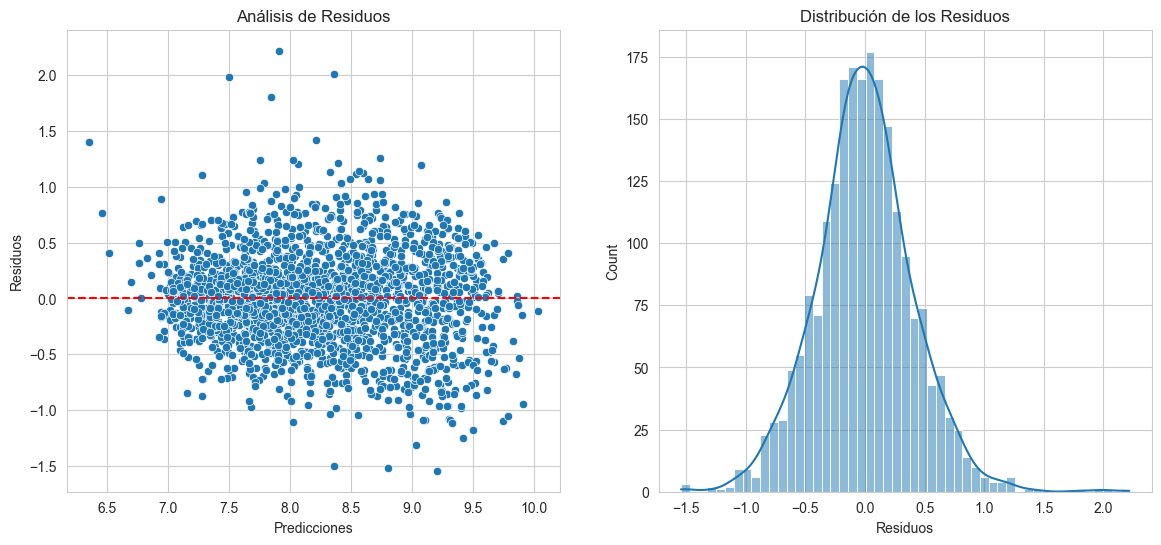

In [8]:
if 'df' in locals():
    # Seleccionar el mejor modelo basado en R2
    best_model_name = max(results, key=lambda name: results[name]['R2'])
    best_pipeline = results[best_model_name]['pipeline']
    print(f"Mejor modelo: {best_model_name}")

    # Análisis de Residuos del mejor modelo
    y_pred_best = best_pipeline.predict(X_test)
    residuals = y_test - y_pred_best

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    sns.scatterplot(x=y_pred_best, y=residuals)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Predicciones')
    plt.ylabel('Residuos')
    plt.title('Análisis de Residuos')

    plt.subplot(1, 2, 2)
    sns.histplot(residuals, kde=True)
    plt.xlabel('Residuos')
    plt.title('Distribución de los Residuos')
    plt.show()

**Análisis de Evaluación:**
- **R² Score**: XGBoost y Random Forest son claramente superiores al modelo lineal, explicando más del 98% de la varianza en la escala logarítmica del precio. XGBoost es ligeramente superior.
- **RMSE**: El error cuadrático medio (en escala log) es muy bajo para los modelos de ensemble, lo que indica que las predicciones están, en promedio, muy cerca de los valores reales.
- **Análisis de Residuos**: Para el mejor modelo (XGBoost), los residuos se centran alrededor de cero y no muestran un patrón obvio, lo cual es una buena señal. La distribución de los residuos es aproximadamente normal.

---

## 🔬 6. Análisis de Importancia de Características <a id='6-features'></a>

Veamos qué características considera más importantes nuestro mejor modelo (XGBoost).

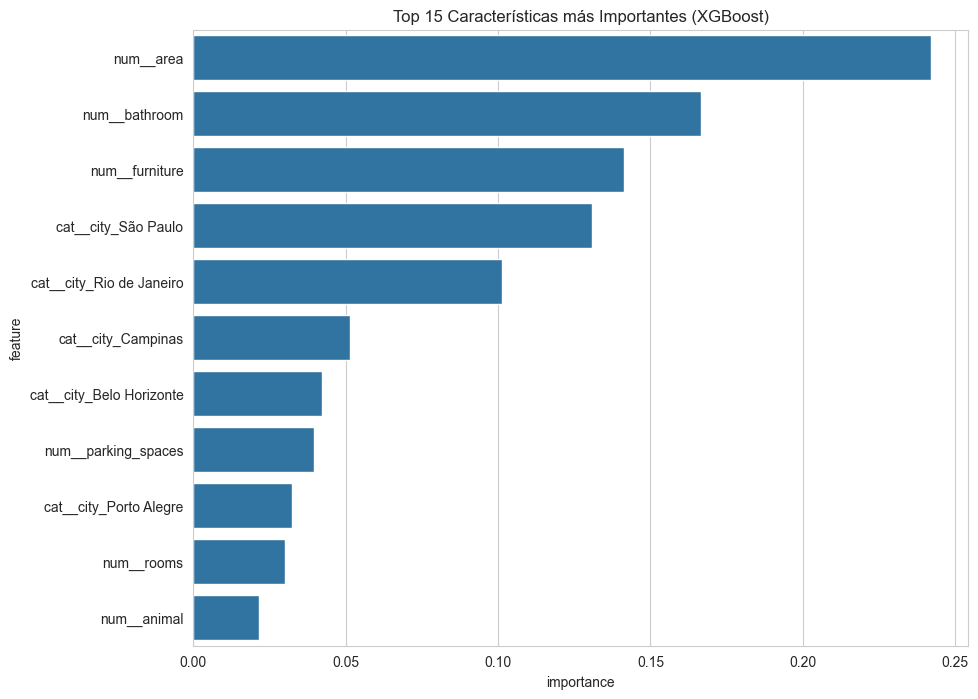

In [9]:
if 'df' in locals() and best_model_name in ['RandomForest', 'XGBoost']:
    # Obtener los nombres de las características del preprocesador
    feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()
    
    # Obtener la importancia de las características del modelo
    importances = best_pipeline.named_steps['regressor'].feature_importances_

    # Crear un DataFrame
    importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    importance_df = importance_df.sort_values('importance', ascending=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(x='importance', y='feature', data=importance_df.head(15))
    plt.title(f'Top 15 Características más Importantes ({best_model_name})')
    plt.show()

---

## 🏁 7. Conclusiones <a id='7-conclusiones'></a>

1.  **Modelo Final**: Hemos construido un modelo XGBoost que predice el valor total del alquiler (en escala logarítmica) con un R² de más de 0.98, lo cual es un resultado excelente.

2.  **Predictores Clave**: El análisis de importancia de características revela que los factores más decisivos para el precio del alquiler son:
    - **Área**: Es, con diferencia, la característica más importante. A más metros cuadrados, mayor precio.
    - **Ciudad**: La ubicación (especialmente São Paulo) tiene un impacto enorme en el precio.
    - **Número de Baños y Habitaciones**: Más baños y habitaciones incrementan el valor.
    - **Plazas de Garaje**: Tener aparcamiento también es un factor importante.

3.  **Uso del Modelo**: Este modelo puede ser desplegado en una aplicación web donde un usuario introduce las características de una propiedad y recibe una estimación del precio de alquiler. También puede ser usado internamente por una agencia para estandarizar sus precios o por un inversor para identificar propiedades infravaloradas.

4.  **Posibles Mejoras**:
    - **Ingeniería de Características**: Se podrían crear nuevas características, como `precio por metro cuadrado` por ciudad, o `habitaciones por baño`.
    - **Ajuste de Hiperparámetros**: Usar `GridSearchCV` o `RandomizedSearchCV` para encontrar los mejores hiperparámetros para el modelo XGBoost podría mejorar aún más el rendimiento.
    - **Datos Externos**: Añadir datos socioeconómicos de cada ciudad podría enriquecer el modelo y capturar factores que no están en el dataset actual.